# Week 7 - Sequence Modeling with RNNs, GRUs, and LSTMs

So far, most of our models have treated examples as fixed-size objects: a vector, an image, or a cropped region. Many data sources are different because order matters. Text, audio, handwriting, sensor streams, financial histories, and biological sequences all contain information that unfolds over time or position.

This week introduces sequence modeling aimed at these data modalities.

The goals are:

1. Understand what makes sequence data different from fixed-size data.
2. Represent text as token IDs and learned embeddings.
3. Explain recurrent hidden state as a learned memory of earlier tokens.
4. Compare mean-pooled embeddings, temporal CNNs, vanilla RNNs, GRUs, LSTMs, and bidirectional LSTMs.
5. Train sequence classifiers on IMDB sentiment data using PyTorch.
6. Diagnose why simple RNNs can struggle with long-range dependencies.
7. Use early stopping and validation curves to compare sequence models fairly.

The running example is IMDB sentiment classification: given a movie review, predict whether the review is positive or negative.


## Imports and Device

The notebook uses plain PyTorch tools: `Dataset`, `DataLoader`, `nn.Embedding`, recurrent layers, optimizers, and evaluation metrics. No transformer layers are used in this week.


In [1]:
# Core Python utilities
from pathlib import Path
from collections import Counter
import os
import re
import shutil
import tarfile
import time
import urllib.request

# Numerical and plotting tools
import numpy as np
import matplotlib.pyplot as plt

# PyTorch tools
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split, Subset

# Reporting tools
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device selection
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

pin_memory = device.type == "cuda"
print(f"Using device: {device}")


Using device: cuda


## What Is a Sequence?

A sequence is an ordered list of observations:

$$x_1, x_2, \ldots, x_T$$

The same elements can mean different things in a different order. For example, "not good" and "good, not great" contain overlapping words but different sentiment.

A recurrent neural network processes one element at a time. At each timestep it updates a hidden state:

$$h_t = f(x_t, h_{t-1})$$

The hidden state is a learned summary of what the model has seen so far. For sequence classification, we often use the final hidden state as a representation of the whole sequence.


## A Tiny Order-Sensitive Task

Before using text, it helps to see why order matters. The synthetic task below creates short token sequences using the symbols `0`, `1`, and `2`.

The label is `1` when the ordered pattern `1, 2` appears anywhere in the sequence. The label is `0` otherwise.

This is intentionally simple: the model does not need vocabulary knowledge or sentiment knowledge. It only needs to learn that a pattern in a sequence can determine the label.


In [2]:
# Synthetic sequence dataset for a small order-sensitive demonstration
class OrderedPatternDataset(Dataset):
    def __init__(self, number_of_examples=4000, sequence_length=10, seed=0):
        generator = torch.Generator().manual_seed(seed)
        positive_count = number_of_examples // 2
        negative_count = number_of_examples - positive_count

        positive_sequences = torch.randint(
            low=0,
            high=3,
            size=(positive_count, sequence_length),
            generator=generator,
        )
        for index in range(positive_count):
            position = torch.randint(
                low=0,
                high=sequence_length - 1,
                size=(1,),
                generator=generator,
            ).item()
            positive_sequences[index, position] = 1
            positive_sequences[index, position + 1] = 2

        negative_sequences = []
        while len(negative_sequences) < negative_count:
            candidate = torch.randint(
                low=0,
                high=3,
                size=(sequence_length,),
                generator=generator,
            )
            contains_pattern = ((candidate[:-1] == 1) & (candidate[1:] == 2)).any().item()
            if not contains_pattern:
                negative_sequences.append(candidate)
        negative_sequences = torch.stack(negative_sequences)

        sequences = torch.cat([positive_sequences, negative_sequences], dim=0)
        labels = torch.cat([
            torch.ones(positive_count, dtype=torch.long),
            torch.zeros(negative_count, dtype=torch.long),
        ])

        permutation = torch.randperm(number_of_examples, generator=generator)
        self.sequences = sequences[permutation]
        self.labels = labels[permutation]

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.labels[index]


synthetic_dataset = OrderedPatternDataset()
synthetic_train_size = int(0.8 * len(synthetic_dataset))
synthetic_val_size = len(synthetic_dataset) - synthetic_train_size
synthetic_train_dataset, synthetic_val_dataset = random_split(
    synthetic_dataset,
    [synthetic_train_size, synthetic_val_size],
    generator=torch.Generator().manual_seed(SEED),
)

synthetic_train_loader = DataLoader(
    synthetic_train_dataset,
    batch_size=128,
    shuffle=True,
    pin_memory=pin_memory,
)
synthetic_val_loader = DataLoader(
    synthetic_val_dataset,
    batch_size=256,
    shuffle=False,
    pin_memory=pin_memory,
)

print(f"Synthetic training examples: {len(synthetic_train_dataset)}")
print(f"Synthetic validation examples: {len(synthetic_val_dataset)}")
print("Example sequence:", synthetic_dataset[0][0].tolist())
print("Example label:", synthetic_dataset[0][1].item())


Synthetic training examples: 3200
Synthetic validation examples: 800
Example sequence: [2, 0, 1, 0, 1, 1, 1, 1, 0, 0]
Example label: 0


In [3]:
# A tiny GRU model for the synthetic sequence task
class TinyPatternGRU(nn.Module):
    def __init__(self, vocab_size=3, embed_dim=8, hidden_dim=16):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
        )
        self.classifier = nn.Linear(hidden_dim, 2)

    def forward(self, token_ids):
        embeddings = self.embedding(token_ids)
        outputs, hidden_state = self.gru(embeddings)
        final_hidden = hidden_state[-1]
        return self.classifier(final_hidden)


def train_multiclass_sequence_model(model, train_loader, val_loader, max_epochs=20, patience=5, lr=1e-3):
    model = model.to(device)
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    history = {"train_loss": [], "val_loss": [], "val_accuracy": []}
    best_val_accuracy = 0.0
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        model.train()
        total_train_loss = 0.0

        for token_ids, labels in train_loader:
            token_ids = token_ids.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(token_ids)
            loss = loss_function(logits, labels)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train_loss += loss.item() * token_ids.size(0)

        average_train_loss = total_train_loss / len(train_loader.dataset)

        model.eval()
        total_val_loss = 0.0
        correct = 0
        seen = 0
        with torch.no_grad():
            for token_ids, labels in val_loader:
                token_ids = token_ids.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                logits = model(token_ids)
                loss = loss_function(logits, labels)

                total_val_loss += loss.item() * token_ids.size(0)
                predictions = logits.argmax(dim=1)
                correct += (predictions == labels).sum().item()
                seen += labels.size(0)

        average_val_loss = total_val_loss / len(val_loader.dataset)
        val_accuracy = correct / seen

        history["train_loss"].append(average_train_loss)
        history["val_loss"].append(average_val_loss)
        history["val_accuracy"].append(val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"Epoch {epoch + 1:03d} | "
            f"Train Loss: {average_train_loss:.4f} | "
            f"Val Loss: {average_val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"No Improve: {epochs_without_improvement}/{patience}"
        )

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_val_accuracy




tiny_gru, tiny_gru_history, tiny_gru_best_accuracy = train_multiclass_sequence_model(
    TinyPatternGRU(),
    synthetic_train_loader,
    synthetic_val_loader,
    max_epochs=20,
    patience=5,
    lr=1e-3,
)
print(f"Best synthetic validation accuracy: {tiny_gru_best_accuracy:.4f}")


Epoch 001 | Train Loss: 0.6680 | Val Loss: 0.6496 | Val Acc: 0.6112 | No Improve: 0/5
Epoch 002 | Train Loss: 0.6375 | Val Loss: 0.6186 | Val Acc: 0.6750 | No Improve: 0/5
Epoch 003 | Train Loss: 0.6043 | Val Loss: 0.5708 | Val Acc: 0.7113 | No Improve: 0/5
Epoch 004 | Train Loss: 0.5476 | Val Loss: 0.4892 | Val Acc: 0.7875 | No Improve: 0/5
Epoch 005 | Train Loss: 0.4588 | Val Loss: 0.3803 | Val Acc: 0.8413 | No Improve: 0/5
Epoch 006 | Train Loss: 0.3582 | Val Loss: 0.2795 | Val Acc: 0.8850 | No Improve: 0/5
Epoch 007 | Train Loss: 0.2408 | Val Loss: 0.1608 | Val Acc: 0.9587 | No Improve: 0/5
Epoch 008 | Train Loss: 0.1175 | Val Loss: 0.0690 | Val Acc: 0.9962 | No Improve: 0/5
Epoch 009 | Train Loss: 0.0490 | Val Loss: 0.0330 | Val Acc: 1.0000 | No Improve: 0/5
Epoch 010 | Train Loss: 0.0271 | Val Loss: 0.0217 | Val Acc: 1.0000 | No Improve: 1/5
Epoch 011 | Train Loss: 0.0188 | Val Loss: 0.0161 | Val Acc: 1.0000 | No Improve: 2/5
Epoch 012 | Train Loss: 0.0143 | Val Loss: 0.0126 | Va

## IMDB Sentiment Data

The main running example is IMDB sentiment classification. Each example is a sequence of words from a movie review. The label is binary:

- `0`: negative review
- `1`: positive review

The original dataset contains 25,000 training reviews and 25,000 test reviews. The notebook uses deterministic training, validation, and test splits so model comparisons use the same examples.


In [4]:
# Download and extract the IMDB dataset if needed
imdb_root = Path("../../datasets/imdb")
archive_path = imdb_root.parent / "aclImdb_v1.tar.gz"
source_url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

if not (imdb_root / "train").exists():
    imdb_root.mkdir(parents=True, exist_ok=True)
    print("Downloading IMDB dataset")
    urllib.request.urlretrieve(source_url, archive_path)

    print("Extracting IMDB dataset")
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=imdb_root.parent)

    extracted_root = imdb_root.parent / "aclImdb"
    if imdb_root.exists():
        shutil.rmtree(imdb_root)
    extracted_root.rename(imdb_root)

print(f"IMDB root: {imdb_root}")


IMDB root: ../../datasets/imdb


## Tokenization and Vocabulary

Neural networks do not operate directly on strings. We convert text into token IDs:

```text
"this movie was great" -> [15, 278, 42, 91]
```

The vocabulary maps common words to integer IDs. Two special IDs are used:

- `<PAD>`: fills short reviews up to a fixed length
- `<OOV>`: represents words outside the vocabulary

This is intentionally simple tokenization. Later NLP systems use more advanced subword tokenizers, but word tokens are enough for learning RNNs and LSTMs.


In [5]:
# Simple tokenizer for IMDB reviews
TOKEN_PATTERN = re.compile(r"\b\w+\b")


def clean_text(text):
    return text.replace("<br />", " ")


def tokenize(text):
    return TOKEN_PATTERN.findall(clean_text(text).lower())


def load_imdb_split(split_root):
    split_root = Path(split_root)
    samples = []
    for class_name, label in [("neg", 0), ("pos", 1)]:
        for path in sorted((split_root / class_name).glob("*.txt")):
            text = path.read_text(encoding="utf-8", errors="ignore")
            samples.append((text, label))
    return samples


train_raw = load_imdb_split(imdb_root / "train")
test_raw = load_imdb_split(imdb_root / "test")

print(f"Raw training reviews: {len(train_raw)}")
print(f"Raw test reviews: {len(test_raw)}")


Raw training reviews: 25000
Raw test reviews: 25000


In [6]:
# Build a vocabulary from training text only
MAX_VOCAB_WORDS = 10000
SEQUENCE_LENGTH = 200


def build_vocabulary(texts, max_words=10000, min_frequency=1):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))

    token_to_id = {"<PAD>": 0, "<OOV>": 1}
    for word, count in counter.most_common():
        if count < min_frequency:
            continue
        if len(token_to_id) >= max_words:
            break
        token_to_id[word] = len(token_to_id)
    return token_to_id


token_to_id = build_vocabulary(
    [text for text, label in train_raw],
    max_words=MAX_VOCAB_WORDS,
)
id_to_token = {index: token for token, index in token_to_id.items()}

print(f"Vocabulary size: {len(token_to_id)}")
print("Most common learned tokens:", [id_to_token[index] for index in range(2, 12)])


Vocabulary size: 10000
Most common learned tokens: ['the', 'and', 'a', 'of', 'to', 'is', 'it', 'in', 'i', 'this']


In [7]:
# Encode one review as a fixed-length vector of token IDs
def encode_text(text, token_to_id, sequence_length):
    token_ids = [token_to_id.get(token, token_to_id["<OOV>"]) for token in tokenize(text)]
    token_ids = token_ids[:sequence_length]

    if len(token_ids) < sequence_length:
        token_ids = token_ids + [token_to_id["<PAD>"]] * (sequence_length - len(token_ids))

    return np.array(token_ids, dtype=np.int64)


example_text, example_label = train_raw[0]
example_ids = encode_text(example_text, token_to_id, SEQUENCE_LENGTH)

print("Example label:", example_label)
print("First 40 token IDs:", example_ids[:40].tolist())
print("First 40 decoded tokens:", [id_to_token.get(index, "<OOV>") for index in example_ids[:40]])


Example label: 0
First 40 token IDs: [63, 5, 4, 125, 36, 47, 7595, 1410, 16, 4, 4239, 512, 45, 17, 4, 628, 134, 12, 7, 4, 1297, 463, 5, 1740, 208, 4, 1, 7494, 303, 7, 673, 83, 35, 2140, 1100, 3023, 34, 2, 908, 1]
First 40 decoded tokens: ['story', 'of', 'a', 'man', 'who', 'has', 'unnatural', 'feelings', 'for', 'a', 'pig', 'starts', 'out', 'with', 'a', 'opening', 'scene', 'that', 'is', 'a', 'terrific', 'example', 'of', 'absurd', 'comedy', 'a', '<OOV>', 'orchestra', 'audience', 'is', 'turned', 'into', 'an', 'insane', 'violent', 'mob', 'by', 'the', 'crazy', '<OOV>']


## Dataset and DataLoaders

The `Dataset` returns one encoded review and one label. The `DataLoader` batches reviews into tensors of shape:

```text
[batch_size, sequence_length]
```

The split sizes below are part of the experiment configuration. Every model uses the same split so architecture comparisons are fair.


In [8]:
# PyTorch Dataset for IMDB sequence classification
class IMDBSequenceDataset(Dataset):
    def __init__(self, samples, token_to_id, sequence_length):
        self.samples = samples
        self.token_to_id = token_to_id
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        text, label = self.samples[index]
        token_ids = encode_text(text, self.token_to_id, self.sequence_length)
        return torch.from_numpy(token_ids), torch.tensor(label, dtype=torch.long)


TRAIN_SUBSET_SIZE = 12000
TEST_SUBSET_SIZE = 8000
BATCH_SIZE = 64
NUM_WORKERS = 2

train_dataset_full = IMDBSequenceDataset(train_raw, token_to_id, SEQUENCE_LENGTH)
test_dataset_full = IMDBSequenceDataset(test_raw, token_to_id, SEQUENCE_LENGTH)

train_indices = torch.randperm(len(train_dataset_full), generator=torch.Generator().manual_seed(SEED))[:TRAIN_SUBSET_SIZE]
test_indices = torch.randperm(len(test_dataset_full), generator=torch.Generator().manual_seed(SEED))[:TEST_SUBSET_SIZE]

train_subset = Subset(train_dataset_full, train_indices.tolist())
eval_subset = Subset(test_dataset_full, test_indices.tolist())

val_size = len(eval_subset) // 2
test_size = len(eval_subset) - val_size
val_dataset, test_dataset = random_split(
    eval_subset,
    [val_size, test_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

print(f"Training examples: {len(train_subset)}")
print(f"Validation examples: {len(val_dataset)}")
print(f"Test examples: {len(test_dataset)}")


Training examples: 12000
Validation examples: 4000
Test examples: 4000


## Embeddings

An embedding layer is a lookup table. If the vocabulary has $V$ tokens and the embedding dimension is $d$, then the embedding matrix has shape:

$$V 	imes d$$

Each token ID selects one row of the embedding matrix. During training, the model learns token vectors that are useful for the task.


In [9]:
# Inspect embedding shapes with one batch
batch_token_ids, batch_labels = next(iter(train_loader))
embedding_layer = nn.Embedding(
    num_embeddings=len(token_to_id),
    embedding_dim=128,
    padding_idx=token_to_id["<PAD>"],
)
embedded_batch = embedding_layer(batch_token_ids)

print(f"Token ID batch shape: {tuple(batch_token_ids.shape)}")
print(f"Embedded batch shape: {tuple(embedded_batch.shape)}")
print(f"Label batch shape: {tuple(batch_labels.shape)}")


Token ID batch shape: (64, 200)
Embedded batch shape: (64, 200, 128)
Label batch shape: (64,)


## Model Zoo for Sequence Classification

The models below all solve the same binary classification task, but they summarize sequences differently.

| Model | Sequence Summary | Main Idea |
|---|---|---|
| Mean-pooled MLP | Average embedding | Ignores order, strong baseline |
| Text CNN | Max over convolution features | Learns local n-gram patterns |
| Simple RNN | Final hidden state | Recurrent memory, but can struggle with long context |
| GRU | Final gated hidden state | Simpler gated recurrence |
| LSTM | Final memory-based hidden state | More stable long-range memory |
| BiLSTM | Forward and backward final states | Uses left and right context |


In [10]:
# Mean-pooled embedding baseline
class MeanPooledTextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, pad_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, token_ids):
        embeddings = self.embedding(token_ids)
        mask = (token_ids != 0).unsqueeze(-1)
        masked_embeddings = embeddings * mask
        lengths = mask.sum(dim=1).clamp(min=1)
        pooled = masked_embeddings.sum(dim=1) / lengths
        return self.classifier(pooled).squeeze(1)


# Temporal CNN baseline
class CNNTextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_filters=128, kernel_sizes=(3, 4, 5), pad_idx=0, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.convolutions = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=kernel_size)
            for kernel_size in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(num_filters * len(kernel_sizes), 1)

    def forward(self, token_ids):
        embeddings = self.embedding(token_ids)
        embeddings = embeddings.transpose(1, 2)
        features = []
        for convolution in self.convolutions:
            activation = torch.relu(convolution(embeddings))
            pooled = activation.max(dim=2).values
            features.append(pooled)
        combined = torch.cat(features, dim=1)
        return self.classifier(self.dropout(combined)).squeeze(1)


In [11]:
# Recurrent text classifiers
class SimpleRNNTextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, pad_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, token_ids):
        embeddings = self.embedding(token_ids)
        outputs, hidden_state = self.rnn(embeddings)
        final_hidden = hidden_state[-1]
        return self.classifier(self.dropout(final_hidden)).squeeze(1)


class GRUTextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, pad_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, token_ids):
        embeddings = self.embedding(token_ids)
        outputs, hidden_state = self.gru(embeddings)
        final_hidden = hidden_state[-1]
        return self.classifier(self.dropout(final_hidden)).squeeze(1)


class LSTMTextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, pad_idx=0, dropout=0.3, bidirectional=False):
        super().__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=bidirectional,
        )
        output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(output_dim, 1)

    def forward(self, token_ids):
        embeddings = self.embedding(token_ids)
        outputs, (hidden_state, cell_state) = self.lstm(embeddings)
        if self.bidirectional:
            final_hidden = torch.cat([hidden_state[-2], hidden_state[-1]], dim=1)
        else:
            final_hidden = hidden_state[-1]
        return self.classifier(self.dropout(final_hidden)).squeeze(1)


## Training and Evaluation

All models use the same training function. The loss is binary cross-entropy with logits:

$$	ext{BCEWithLogitsLoss}(z, y)$$

where $z$ is the raw model logit and $y \in \{0, 1\}$. Early stopping prevents wasting time after validation performance stops improving.


In [12]:
# Helpers for binary sequence classification
def binary_accuracy_from_logits(logits, labels):
    predictions = (torch.sigmoid(logits) >= 0.5).long()
    return (predictions == labels).float().mean().item()


def evaluate_binary_classifier(model, data_loader, loss_function):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_seen = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for token_ids, labels in data_loader:
            token_ids = token_ids.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(token_ids)
            loss = loss_function(logits, labels.float())

            predictions = (torch.sigmoid(logits) >= 0.5).long()
            total_loss += loss.item() * labels.size(0)
            total_correct += (predictions == labels).sum().item()
            total_seen += labels.size(0)
            all_predictions.append(predictions.cpu())
            all_labels.append(labels.cpu())

    return {
        "loss": total_loss / total_seen,
        "accuracy": total_correct / total_seen,
        "predictions": torch.cat(all_predictions),
        "labels": torch.cat(all_labels),
    }


In [13]:
# Reusable training loop for IMDB sequence models
def train_text_classifier(
    model,
    model_name,
    train_loader,
    val_loader,
    test_loader,
    *,
    max_epochs=20,
    patience=5,
    learning_rate=3e-4,
    weight_decay=1e-4,
    gradient_clip=1.0,
):
    model = model.to(device)
    loss_function = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    history = {"train_loss": [], "val_loss": [], "val_accuracy": []}
    best_val_accuracy = 0.0
    best_state = None
    epochs_without_improvement = 0
    checkpoint_path = Path(f"best_{model_name}.pt")

    for epoch in range(max_epochs):
        start_time = time.time()
        model.train()
        total_train_loss = 0.0
        total_seen = 0

        for token_ids, labels in train_loader:
            token_ids = token_ids.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(token_ids)
            loss = loss_function(logits, labels.float())

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            if gradient_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
            optimizer.step()

            total_train_loss += loss.item() * labels.size(0)
            total_seen += labels.size(0)

        train_loss = total_train_loss / total_seen
        val_metrics = evaluate_binary_classifier(model, val_loader, loss_function)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])

        if val_metrics["accuracy"] > best_val_accuracy:
            best_val_accuracy = val_metrics["accuracy"]
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            torch.save(
                {
                    "model_state": best_state,
                    "history": history,
                    "best_val_accuracy": best_val_accuracy,
                },
                checkpoint_path,
            )
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"{model_name:<10} | Epoch {epoch + 1:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Acc: {val_metrics['accuracy']:.4f} | "
            f"No Improve: {epochs_without_improvement}/{patience} | "
            f"Time: {time.time() - start_time:.1f}s"
        )

        if epochs_without_improvement >= patience:
            print(f"Early stopping {model_name} at epoch {epoch + 1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = evaluate_binary_classifier(model, test_loader, loss_function)
    print(f"{model_name} test accuracy: {test_metrics['accuracy']:.4f}")

    return {
        "model": model,
        "history": history,
        "best_val_accuracy": best_val_accuracy,
        "test_accuracy": test_metrics["accuracy"],
        "test_predictions": test_metrics["predictions"],
        "test_labels": test_metrics["labels"],
        "checkpoint_path": str(checkpoint_path),
    }


## Train the Model Zoo

The same IMDB data, sequence length, vocabulary, optimizer, and early stopping settings are used for each model. This makes the comparison mostly about how each architecture represents a sequence.


In [14]:
# Model factory for the IMDB experiments
vocab_size = len(token_to_id)
pad_idx = token_to_id["<PAD>"]


def make_text_model(model_name):
    model_name = model_name.lower()
    if model_name == "mean_mlp":
        return MeanPooledTextClassifier(vocab_size, pad_idx=pad_idx)
    if model_name == "cnn":
        return CNNTextClassifier(vocab_size, pad_idx=pad_idx)
    if model_name == "rnn":
        return SimpleRNNTextClassifier(vocab_size, embed_dim=128, hidden_dim=128, pad_idx=pad_idx)
    if model_name == "gru":
        return GRUTextClassifier(vocab_size, embed_dim=128, hidden_dim=128, pad_idx=pad_idx)
    if model_name == "lstm":
        return LSTMTextClassifier(vocab_size, embed_dim=128, hidden_dim=128, pad_idx=pad_idx)
    if model_name == "bilstm":
        return LSTMTextClassifier(vocab_size, embed_dim=128, hidden_dim=128, pad_idx=pad_idx, bidirectional=True)
    raise ValueError(f"Unknown model name: {model_name}")


model_order = ["mean_mlp", "cnn", "rnn", "gru", "lstm", "bilstm"]
results = {}

for model_name in model_order:
    print("\n" + "=" * 72)
    print(f"Training {model_name}")
    print("=" * 72)

    model = make_text_model(model_name)
    results[model_name] = train_text_classifier(
        model,
        model_name,
        train_loader,
        val_loader,
        test_loader,
        max_epochs=20,
        patience=5,
        learning_rate=3e-4,
        weight_decay=1e-4,
        gradient_clip=1.0,
    )



Training mean_mlp
mean_mlp   | Epoch 001 | Train Loss: 0.6782 | Val Loss: 0.6595 | Val Acc: 0.6315 | No Improve: 0/5 | Time: 0.8s
mean_mlp   | Epoch 002 | Train Loss: 0.6124 | Val Loss: 0.5821 | Val Acc: 0.7037 | No Improve: 0/5 | Time: 0.7s
mean_mlp   | Epoch 003 | Train Loss: 0.5203 | Val Loss: 0.5124 | Val Acc: 0.7470 | No Improve: 0/5 | Time: 0.7s
mean_mlp   | Epoch 004 | Train Loss: 0.4431 | Val Loss: 0.4672 | Val Acc: 0.7755 | No Improve: 0/5 | Time: 0.7s
mean_mlp   | Epoch 005 | Train Loss: 0.3921 | Val Loss: 0.4417 | Val Acc: 0.7930 | No Improve: 0/5 | Time: 0.7s
mean_mlp   | Epoch 006 | Train Loss: 0.3537 | Val Loss: 0.4222 | Val Acc: 0.8040 | No Improve: 0/5 | Time: 0.7s
mean_mlp   | Epoch 007 | Train Loss: 0.3260 | Val Loss: 0.4111 | Val Acc: 0.8103 | No Improve: 0/5 | Time: 0.6s
mean_mlp   | Epoch 008 | Train Loss: 0.3015 | Val Loss: 0.4036 | Val Acc: 0.8193 | No Improve: 0/5 | Time: 0.7s
mean_mlp   | Epoch 009 | Train Loss: 0.2812 | Val Loss: 0.3997 | Val Acc: 0.8247 | No

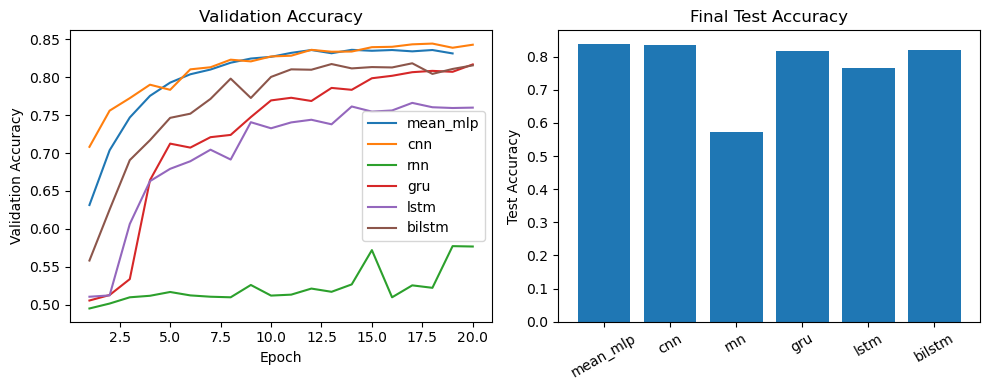

Model          Best Val Acc   Test Acc
----------------------------------------
mean_mlp             0.8363     0.8375
cnn                  0.8445     0.8345
rnn                  0.5773     0.5723
gru                  0.8170     0.8170
lstm                 0.7662     0.7645
bilstm               0.8185     0.8200


In [15]:
# Compare validation curves and final test accuracy
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
for model_name, result in results.items():
    history = result["history"]
    epochs = range(1, len(history["val_accuracy"]) + 1)
    plt.plot(epochs, history["val_accuracy"], label=model_name)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
model_names = list(results.keys())
test_accuracies = [results[name]["test_accuracy"] for name in model_names]
plt.bar(model_names, test_accuracies)
plt.ylabel("Test Accuracy")
plt.title("Final Test Accuracy")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

print(f"{'Model':<12} {'Best Val Acc':>14} {'Test Acc':>10}")
print("-" * 40)
for model_name, result in results.items():
    print(f"{model_name:<12} {result['best_val_accuracy']:>14.4f} {result['test_accuracy']:>10.4f}")


## Error Analysis

Accuracy is useful, but examples are more memorable. The cell below prints a few reviews that the best model misclassified. This is often where sentiment analysis becomes interesting: sarcasm, mixed reviews, negation, long context, and ambiguous language can all fool sequence models.


In [16]:
# Inspect mistakes from the best model
best_model_name = max(results, key=lambda name: results[name]["test_accuracy"])
best_result = results[best_model_name]
predictions = best_result["test_predictions"]
labels = best_result["test_labels"]

mistake_indices = (predictions != labels).nonzero(as_tuple=True)[0]
print(f"Best model: {best_model_name}")
print(f"Number of test mistakes: {len(mistake_indices)}")

for display_index in mistake_indices[:5]:
    subset_index = test_dataset.indices[int(display_index)]
    original_index = eval_subset.indices[subset_index]
    review_text, true_label = test_raw[original_index]
    predicted_label = int(predictions[int(display_index)])

    print("=" * 80)
    print(f"True label: {true_label} | Predicted label: {predicted_label}")
    print(clean_text(review_text)[:900], "...")


Best model: mean_mlp
Number of test mistakes: 650
True label: 1 | Predicted label: 0
And a hard spot somewhere else. I haven't seen this movie since i was quite young, maybe 12 or 13, who knows. But what i do know is this is the movie that taught me how to masturbate. I kid you not. I have no idea if it is any good by any real standards of today, but for me, back then, it was everything.  The only reason i feel comfortable writing this is because i'm sure no one will ever get around to reading it. I mean, really, who is going to look up this movie these days?  I just discovered that i have not yet used up the ten line minimum for the amount of length i most take up in a review. i had no idea there was such a minimum length, but there i go, like a student trying to fill up a page in a journal, my ten lines. thank you very much. ...
True label: 1 | Predicted label: 0
This film reappeared on channel 13 in the 1990s when they did a series of comedies from Hollywood in the 1930s and 1940s. 

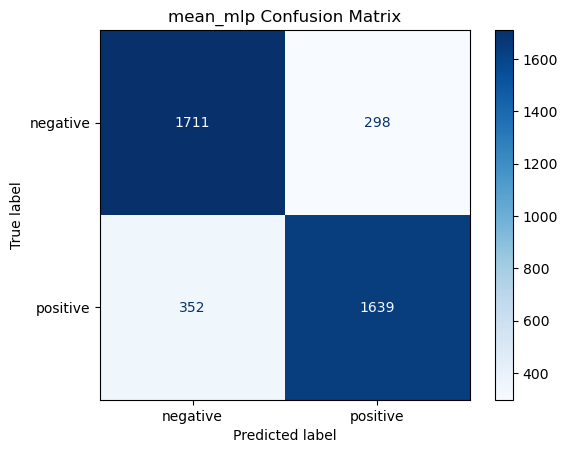

              precision    recall  f1-score   support

    negative       0.83      0.85      0.84      2009
    positive       0.85      0.82      0.83      1991

    accuracy                           0.84      4000
   macro avg       0.84      0.84      0.84      4000
weighted avg       0.84      0.84      0.84      4000



In [17]:
# Confusion matrix for the best model
ConfusionMatrixDisplay.from_predictions(
    labels.numpy(),
    predictions.numpy(),
    display_labels=["negative", "positive"],
    cmap="Blues",
)
plt.title(f"{best_model_name} Confusion Matrix")
plt.show()

print(classification_report(
    labels.numpy(),
    predictions.numpy(),
    target_names=["negative", "positive"],
))


## Why Simple RNNs Struggle

A vanilla RNN repeatedly applies the same kind of update:

$$h_t = 	\tanh(W_x x_t + W_h h_{t-1} + b)$$

During backpropagation through time, gradients must pass through many repeated multiplications. They can shrink toward zero or grow too large. This is one reason simple RNNs often struggle with long-range dependencies.

GRUs and LSTMs add gates. Gates let the model learn when to keep, erase, or update information. This makes it easier to preserve useful context across many timesteps.


## Takeaways

Sequence models process ordered data. A recurrent model maintains a hidden state that changes as it reads the sequence.

Mean-pooled embeddings are fast and useful, but they mostly ignore order. CNNs capture local word patterns. Simple RNNs introduce sequential memory, while GRUs and LSTMs improve memory with gates. Bidirectional LSTMs use both left and right context when the whole sequence is available.

For IMDB sentiment classification, the best model is not guaranteed to be the most complex one. Data size, sequence length, vocabulary, optimization, and regularization all matter. The important habit is to compare models under the same data split and training procedure.

This week focuses on recurrent sequence models: RNNs, GRUs, and LSTMs.
